# Student Performance Predictor
## Exploratory Data Analysis & Model Training
**Dataset:** Students Performance in Exams (Kaggle)  
**Goal:** Predict a student's average score based on demographic and preparation factors

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
print("Libraries loaded successfully")

Libraries loaded successfully


In [65]:
data = pd.read_csv('../data/raw/StudentsPerformance.csv')

# Rename columns
data.columns = data.columns.str.replace(' ', '_').str.lower()

print("Shape:", data.shape)
data.head()

Shape: (1000, 8)


,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [66]:
print("=== Missing Values ===")
print(data.isnull().sum())

print("\n=== Data Types ===")
print(data.dtypes)

print("\n=== Duplicates ===")
print("Duplicate rows:", data.duplicated().sum())

=== Missing Values ===
gender                         0
race/ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

=== Data Types ===
gender                           str
race/ethnicity                   str
parental_level_of_education      str
lunch                            str
test_preparation_course          str
math_score                     int64
reading_score                  int64
writing_score                  int64
dtype: object

=== Duplicates ===
Duplicate rows: 0


## Feature Engineering
Creating a new target column: `average_score` = mean of all 3 subject scores

In [67]:
data['average_score'] = (data['math_score'] + data['reading_score'] + data['writing_score']) / 3

# Also create a grade label (useful for classification later)
def get_grade(score):
    if score >= 80: return 'A'
    elif score >= 60: return 'B'
    elif score >= 40: return 'C'
    else: return 'D'

data['grade'] = data['average_score'].apply(get_grade)

print(data[['math_score', 'reading_score', 'writing_score', 'average_score', 'grade']].head())

   math_score  reading_score  writing_score  average_score grade
0          72             72             74      72.666667     B
1          69             90             88      82.333333     A
2          90             95             93      92.666667     A
3          47             57             44      49.333333     C
4          76             78             75      76.333333     B


## Score Distributions
How are math, reading, and writing scores distributed across students?

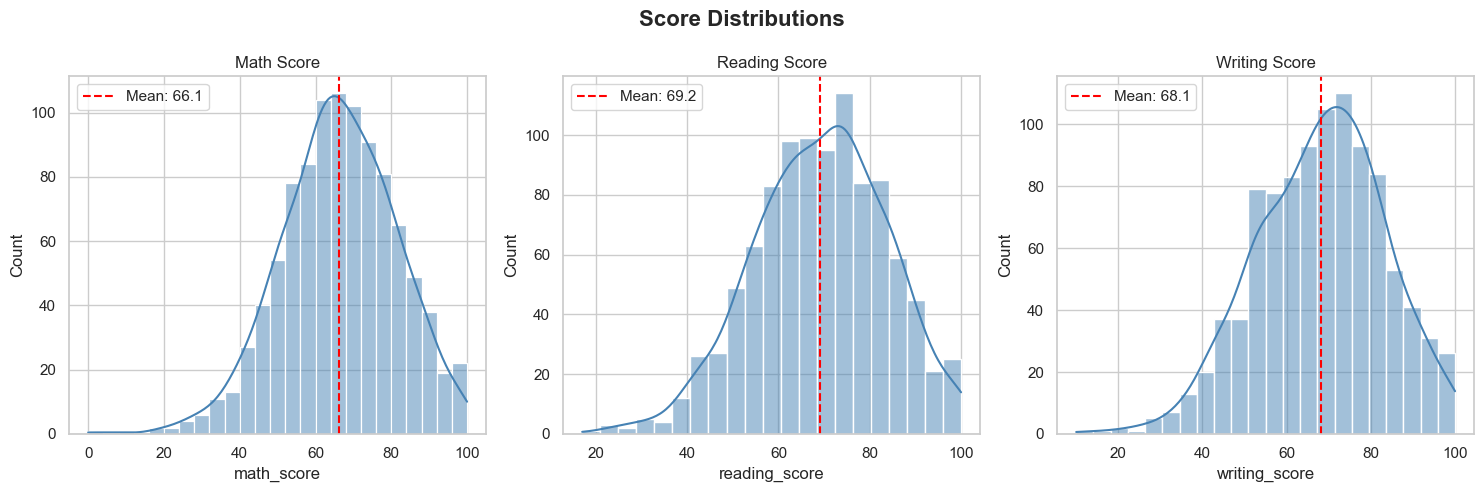

Saved to data/processed/


In [68]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Score Distributions', fontsize=16, fontweight='bold')

for ax, col in zip(axes, ['math_score', 'reading_score', 'writing_score']):
    sns.histplot(data[col], ax=ax, kde=True, color='steelblue')
    ax.axvline(data[col].mean(), color='red', linestyle='--', label=f'Mean: {data[col].mean():.1f}')
    ax.set_title(col.replace('_', ' ').title())
    ax.legend()

plt.tight_layout()
plt.savefig('../data/processed/score_distribution.png', dpi=150)
plt.show()
print("Saved to data/processed/")

## Gender vs Performance
Do male and female students perform differently?

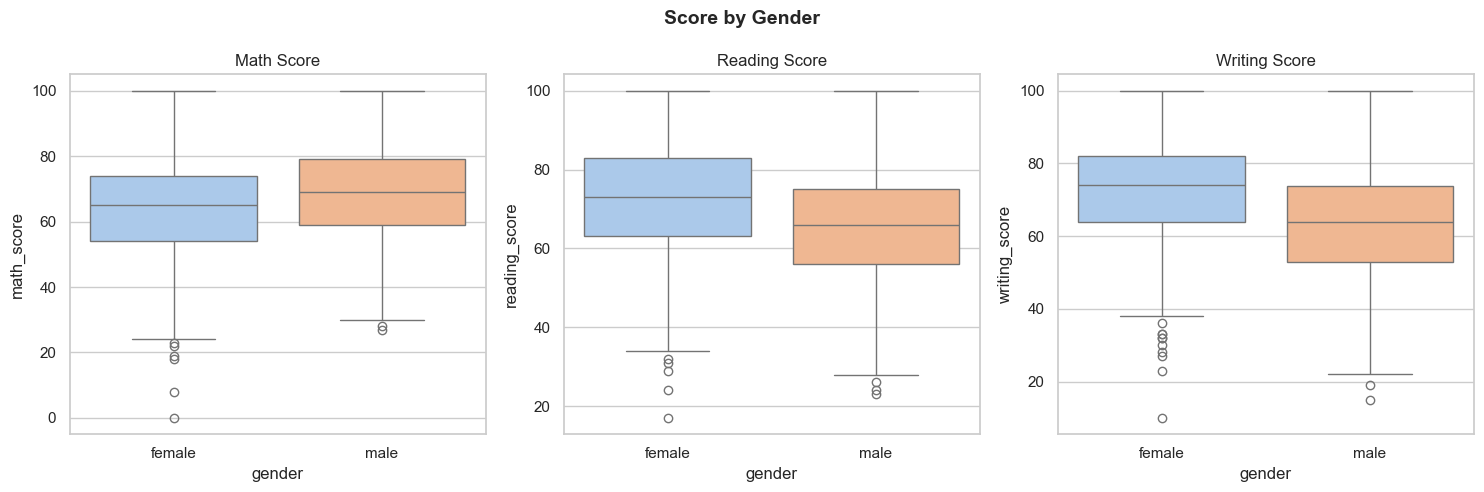

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Score by Gender', fontsize=14, fontweight='bold')

for ax, col in zip(axes, ['math_score', 'reading_score', 'writing_score']):
    sns.boxplot(data=data, x='gender', y=col, ax=ax, palette='pastel')
    ax.set_title(col.replace('_', ' ').title())

plt.tight_layout()
plt.savefig('../data/processed/gender_analysis.png', dpi=150)
plt.show()

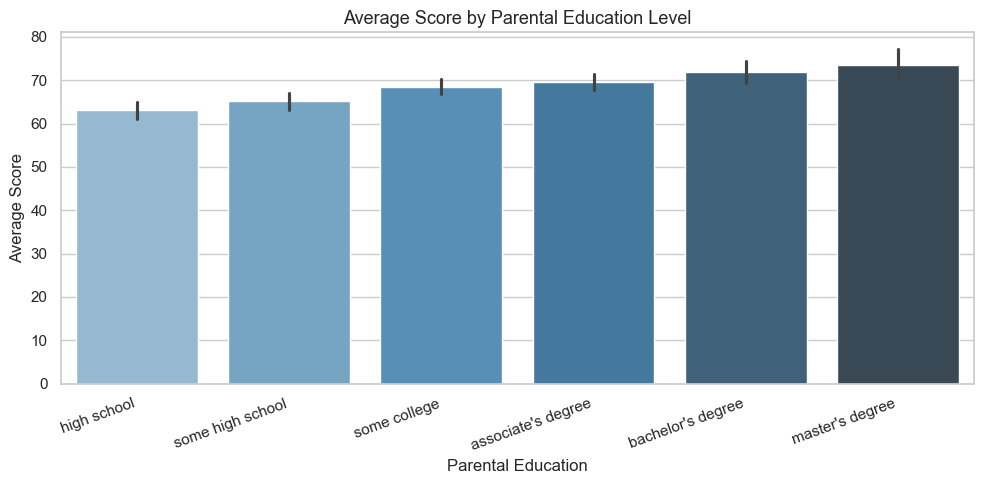

In [70]:
fig, ax = plt.subplots(figsize=(10, 5))
order = data.groupby('parental_level_of_education')['average_score'].mean().sort_values().index
sns.barplot(data=data, x='parental_level_of_education', y='average_score',
            order=order, palette='Blues_d', ax=ax)
ax.set_title("Average Score by Parental Education Level", fontsize=13)
ax.set_xlabel("Parental Education")
ax.set_ylabel("Average Score")
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('../data/processed/parental_education.png', dpi=150)
plt.show()

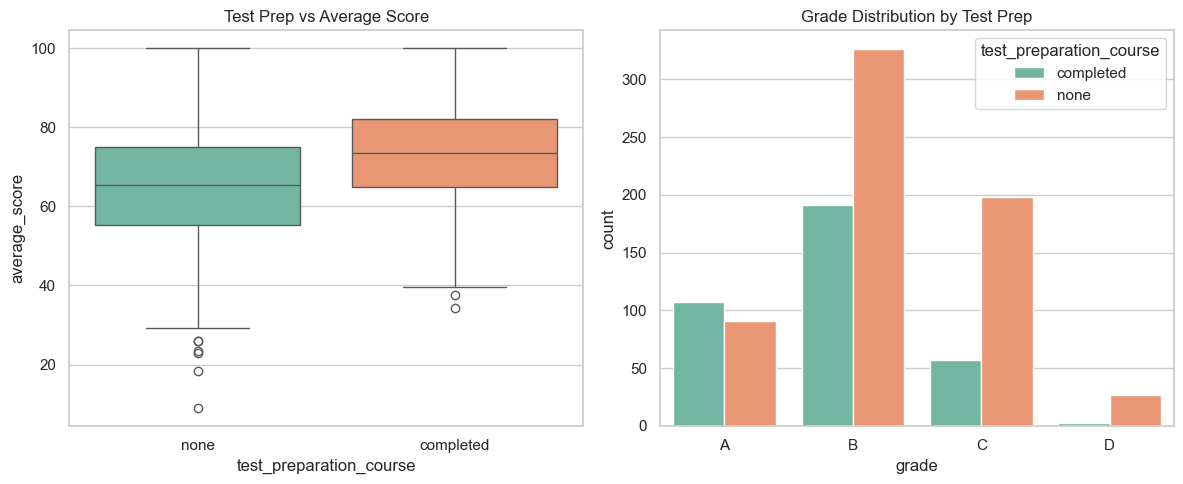

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot
sns.boxplot(data=data, x='test_preparation_course', y='average_score',
            palette='Set2', ax=axes[0])
axes[0].set_title('Test Prep vs Average Score')

# Count of grades
grade_prep = data.groupby(['test_preparation_course', 'grade']).size().reset_index(name='count')
sns.barplot(data=grade_prep, x='grade', y='count',
            hue='test_preparation_course', palette='Set2', ax=axes[1])
axes[1].set_title('Grade Distribution by Test Prep')

plt.tight_layout()
plt.savefig('../data/processed/test_prep_analysis.png', dpi=150)
plt.show()

## Correlation Between Scores
Are the three subject scores correlated with each other?

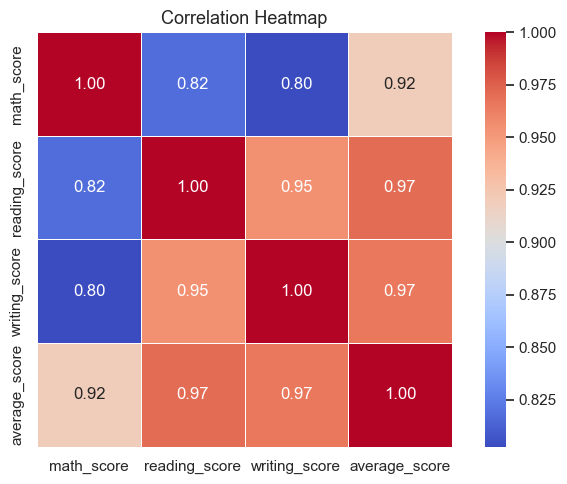

In [72]:
corr = data[['math_score', 'reading_score', 'writing_score', 'average_score']].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/correlation_heatmap.png', dpi=150)
plt.show()

## Key Insights from EDA

1. **No missing values** — dataset is clean and ready for modeling
2. **Scores are roughly normally distributed** — good for regression models
3. **Test preparation course** significantly improves scores across all subjects
4. **Parental education level** shows a positive correlation with student performance
5. **Reading and writing scores** are highly correlated (r ≈ 0.95)
6. **Gender gap** — females score higher in reading/writing; males slightly higher in math

## Next Step → Preprocessing and Feature Engineering

In [73]:
import pandas as pd
df.to_csv('../data/processed/students_cleaned.csv', index=False)
print("Cleaned dataset saved!")
print(f"Final shape: {df.shape}")
df.head()

Cleaned dataset saved!
Final shape: (1000, 10)


,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,average_score,grade
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,B
1,female,group C,some college,standard,completed,69,90,88,82.333333,A
2,female,group B,master's degree,standard,none,90,95,93,92.666667,A
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,C
4,male,group C,some college,standard,none,76,78,75,76.333333,B


---
## Phase 3 — Data Preprocessing & Feature Engineering
Preparing data for model training: encoding categories and building the pipeline.

In [74]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

print("Preprocessing libraries loaded!")

Preprocessing libraries loaded!


In [75]:

# X = input features (what the model learns FROM)
# y = target (what the model learns TO predict)
import pandas as pd
df=pd.read_csv('../data/processed/students_cleaned.csv')
X = df.drop(columns=['math_score', 'reading_score', 'writing_score', 'average_score', 'grade'])
y = df['average_score']

print("X shape:", X.shape)    # should be (1000, 5)
print("y shape:", y.shape)    # should be (1000,)
print("\nFeatures used:")
print(X.columns.tolist())
print("\nSample X:")
print(X.head())




X shape: (1000, 5)
y shape: (1000,)

Features used:
['gender', 'race/ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']

Sample X:
   gender race/ethnicity parental_level_of_education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test_preparation_course  
0                    none  
1               completed  
2                    none  
3                    none  
4                    none  


In [76]:
# Find which columns are categorical (text)
categorical_cols = X.select_dtypes(include='object').columns.tolist()

# Find which columns are numerical
numerical_cols = X.select_dtypes(include='number').columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

# Check unique values in each categorical column
for col in categorical_cols:
    print(f"\n{col} ({len(df[col].unique())} unique values):")
    print(df[col].unique())

Categorical columns: ['gender', 'race/ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']
Numerical columns: []

gender (2 unique values):
<StringArray>
['female', 'male']
Length: 2, dtype: str

race/ethnicity (5 unique values):
<StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str

parental_level_of_education (6 unique values):
<StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str

lunch (2 unique values):
<StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str

test_preparation_course (2 unique values):
<StringArray>
['none', 'completed']
Length: 2, dtype: str


In [77]:
# Let's manually see what OneHotEncoding does BEFORE applying it
# Example with just the 'gender' column

example = pd.get_dummies(df[['gender']], drop_first=False).astype(int)
print("Original 'gender' column:")
print(df['gender'].head(8).to_string())
print("\nAfter OneHotEncoding:")
print(example.head(8).to_string())

Original 'gender' column:
0    female
1    female
2    female
3      male
4      male
5    female
6    female
7      male

After OneHotEncoding:
   gender_female  gender_male
0              1            0
1              1            0
2              1            0
3              0            1
4              0            1
5              1            0
6              1            0
7              0            1


In [78]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing, 80% for training
    random_state=42     # fixed seed so results are reproducible
)

print("Training set size:", X_train.shape)    # ~800 rows
print("Testing set size:", X_test.shape)      # ~200 rows
print("\nTraining target sample:")
print(y_train.head())

Training set size: (800, 5)
Testing set size: (200, 5)

Training target sample:
29     69.000000
535    77.333333
695    84.666667
557    64.666667
836    64.666667
Name: average_score, dtype: float64


In [79]:
# Preprocessor handles categorical and numerical columns separately
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        # Format: ('name', transformer_object, list_of_columns)
    ],
    remainder='drop'  # drop any columns not specified above
)

print("Preprocessor created!")
print("\nIt will apply OneHotEncoder to:")
print(categorical_cols)

Preprocessor created!

It will apply OneHotEncoder to:
['gender', 'race/ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [80]:
# Fit and transform just to SEE what the output looks like
X_train_transformed = preprocessor.fit_transform(X_train)

print("Shape BEFORE preprocessing:", X_train.shape)
print("Shape AFTER preprocessing:", X_train_transformed.shape)
print("\nOriginal had 5 columns.")
print("After OneHotEncoding, we have", X_train_transformed.shape[1], "columns")
print("(because each category value becomes its own column)")

Shape BEFORE preprocessing: (800, 5)
Shape AFTER preprocessing: (800, 17)

Original had 5 columns.
After OneHotEncoding, we have 17 columns
(because each category value becomes its own column)


In [81]:
from sklearn.linear_model import LinearRegression

# Pipeline chains preprocessing + model together
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# One line does everything:
# 1. Encodes the text columns
# 2. Trains the model on the result
pipeline.fit(X_train, y_train)

print("Pipeline trained successfully!")
print("\nPipeline steps:")
for name, step in pipeline.steps:
    print(f"  → {name}: {type(step).__name__}")

Pipeline trained successfully!

Pipeline steps:
  → preprocessor: ColumnTransformer
  → model: LinearRegression


In [82]:
# Create a sample student to predict
sample_student = pd.DataFrame({
    'gender': ['female'],
    'race/ethnicity': ['group B'],
    'parental_level_of_education': ["bachelor's degree"],
    'lunch': ['standard'],
    'test_preparation_course': ['completed']
})

predicted_score = pipeline.predict(sample_student)[0]
print(f"Predicted average score: {predicted_score:.2f} / 100")

Predicted average score: 80.84 / 100


In [83]:
import pickle

# Save the pipeline (preprocessor is inside it)
with open('../models/preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

# Save cleaned dataframe for later use
df.to_csv('../data/processed/students_cleaned.csv', index=False)

print("Preprocessor saved to models/preprocessor.pkl")
print("Cleaned data saved to data/processed/students_cleaned.csv")

Preprocessor saved to models/preprocessor.pkl
Cleaned data saved to data/processed/students_cleaned.csv


In [84]:
# See all categorical columns and their unique values at once
for col in X.select_dtypes(include='object').columns:
    print(f"\n{col}")
    print(f"  Unique values ({df[col].nunique()}):", df[col].unique())
    print(f"  Value counts:\n{df[col].value_counts().to_string()}")


gender
  Unique values (2): <StringArray>
['female', 'male']
Length: 2, dtype: str
  Value counts:
gender
female    518
male      482

race/ethnicity
  Unique values (5): <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
  Value counts:
race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89

parental_level_of_education
  Unique values (6): <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
  Value counts:
parental_level_of_education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59

lunch
  Unique values (2): <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
  Value counts:
lunch
standard        645
free/reduced    355

test_preparation_course
  Unique values (2): <StringAr

In [85]:
# Verify your pipeline structure
print("Pipeline steps:")
for step_name, step_object in pipeline.steps:
    print(f"  {step_name}: {type(step_object).__name__}")

print("\nTest prediction on one sample:")
sample = X_test.iloc[[0]]   # take first test row
print("Input:", sample.values)
print("Predicted score:", round(float(pipeline.predict(sample)[0]), 2))
print("Actual score:", round(y_test.iloc[0], 2))

Pipeline steps:
  preprocessor: ColumnTransformer
  model: LinearRegression

Test prediction on one sample:
Input: [['female' 'group C' "associate's degree" 'standard' 'none']]
Predicted score: 70.52
Actual score: 87.0


---
## Phase 4 — Model Training & Evaluation
Training multiple regression models, comparing performance, and selecting the best one.

**Models we'll compare:**
- Linear Regression
- Decision Tree
- Random Forest
- Gradient Boosting

In [86]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
import pickle
import warnings
warnings.filterwarnings('ignore')

print("All model libraries loaded!")

All model libraries loaded!


### What each model does

| Model | How it works | Good at |
|---|---|---|
| **Linear Regression** | Draws best straight line through data | Simple relationships |
| **Decision Tree** | Makes yes/no decisions like a flowchart | Non-linear patterns |
| **Random Forest** | 100 decision trees voting together | Complex patterns, robust |
| **Gradient Boosting** | Trees that fix each other's mistakes | Best accuracy usually |

In [87]:
models = {
    'Linear Regression':    LinearRegression(),
    'Decision Tree':        DecisionTreeRegressor(random_state=42),
    'Random Forest':        RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':    GradientBoostingRegressor(n_estimators=100, random_state=42)
}

print(f"Total models to train: {len(models)}")
for name in models:
    print(f"  → {name}")

Total models to train: 4
  → Linear Regression
  → Decision Tree
  → Random Forest
  → Gradient Boosting


In [88]:
# Store results here
results = {}

print("Training models...\n")
print(f"{'Model':<25} {'R² Score':>10} {'MAE':>10} {'RMSE':>10}")
print("-" * 58)

for name, model in models.items():

    # Build pipeline for each model
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # Train the model
    pipe.fit(X_train, y_train)

    # Predict on test data
    y_pred = pipe.predict(X_test)

    # Calculate metrics
    r2   = r2_score(y_test, y_pred)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5

    # Store results
    results[name] = {
        'pipeline': pipe,
        'R2':   round(r2,   4),
        'MAE':  round(mae,  4),
        'RMSE': round(rmse, 4)
    }

    print(f"{name:<25} {r2:>10.4f} {mae:>10.4f} {rmse:>10.4f}")

print("\nAll models trained successfully!")

Training models...

Model                       R² Score        MAE       RMSE
----------------------------------------------------------
Linear Regression             0.1622    10.4902    13.4016
Decision Tree                -0.0753    11.8081    15.1827
Random Forest                -0.0260    11.4930    14.8303
Gradient Boosting             0.0858    10.8320    13.9993

All models trained successfully!


### What do these metrics mean?

**R² Score (R-squared)**
- Range: 0 to 1 (higher is better)
- R² = 0.93 means the model explains 93% of the variation in scores
- R² = 1.0 would be perfect prediction
- R² below 0.7 is generally considered weak

**MAE (Mean Absolute Error)**
- Average difference between predicted and actual scores
- MAE = 3.56 means predictions are off by ~3.56 points on average
- Lower is better. In a 0-100 score range, under 5 is good

**RMSE (Root Mean Squared Error)**  
- Similar to MAE but penalizes large errors more heavily
- Lower is better
- If RMSE >> MAE, your model makes some very large mistakes

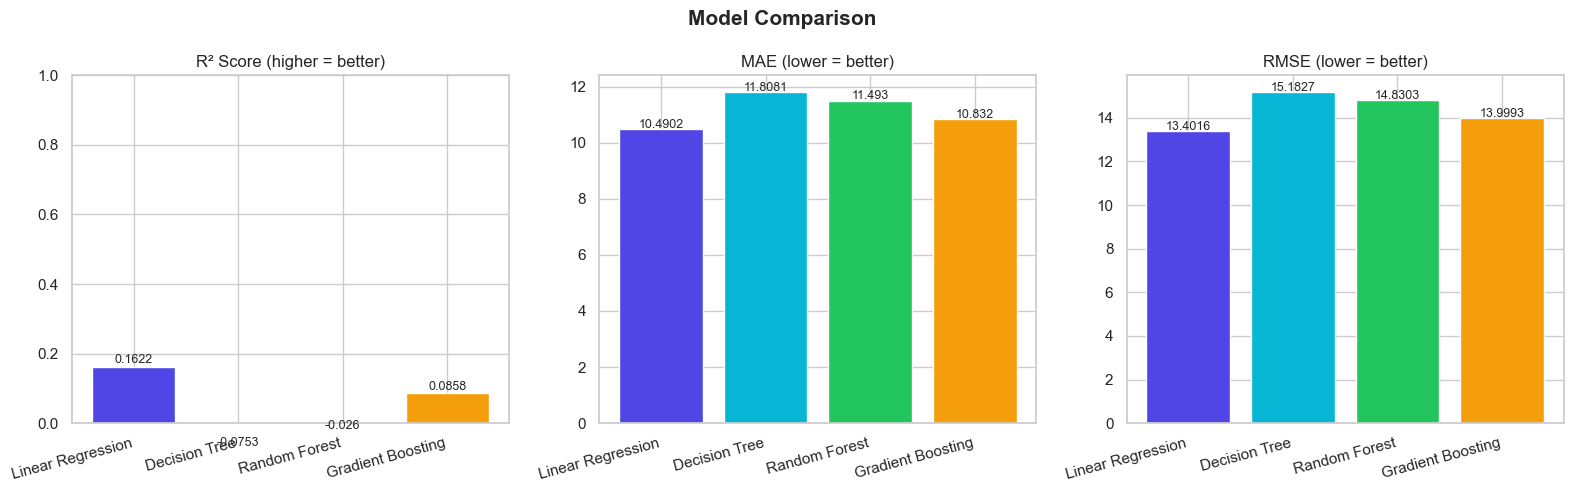

Chart saved!


In [89]:
import matplotlib.pyplot as plt
import numpy as np

model_names = list(results.keys())
r2_scores   = [results[m]['R2']   for m in model_names]
mae_scores  = [results[m]['MAE']  for m in model_names]
rmse_scores = [results[m]['RMSE'] for m in model_names]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Comparison', fontsize=15, fontweight='bold')

colors = ['#4f46e5', '#06b6d4', '#22c55e', '#f59e0b']

# R2 Score
axes[0].bar(model_names, r2_scores, color=colors)
axes[0].set_title('R² Score (higher = better)')
axes[0].set_ylim(0, 1)
axes[0].set_xticklabels(model_names, rotation=15, ha='right')
for i, v in enumerate(r2_scores):
    axes[0].text(i, v + 0.01, str(v), ha='center', fontsize=9)

# MAE
axes[1].bar(model_names, mae_scores, color=colors)
axes[1].set_title('MAE (lower = better)')
axes[1].set_xticklabels(model_names, rotation=15, ha='right')
for i, v in enumerate(mae_scores):
    axes[1].text(i, v + 0.05, str(v), ha='center', fontsize=9)

# RMSE
axes[2].bar(model_names, rmse_scores, color=colors)
axes[2].set_title('RMSE (lower = better)')
axes[2].set_xticklabels(model_names, rotation=15, ha='right')
for i, v in enumerate(rmse_scores):
    axes[2].text(i, v + 0.05, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../data/processed/model_comparison.png', dpi=150)
plt.show()
print("Chart saved!")

In [90]:
# Select model with highest R² score
best_model_name = max(
    results,
    key=lambda name: results[name]['R2']
)

best_result = results[best_model_name]

print("=" * 45)
print(f"  BEST MODEL: {best_model_name}")
print("=" * 45)
print(f"  R² Score : {best_result['R2']}")
print(f"  MAE      : {best_result['MAE']}")
print(f"  RMSE     : {best_result['RMSE']}")
print("=" * 45)

  BEST MODEL: Linear Regression
  R² Score : 0.1622
  MAE      : 10.4902
  RMSE     : 13.4016


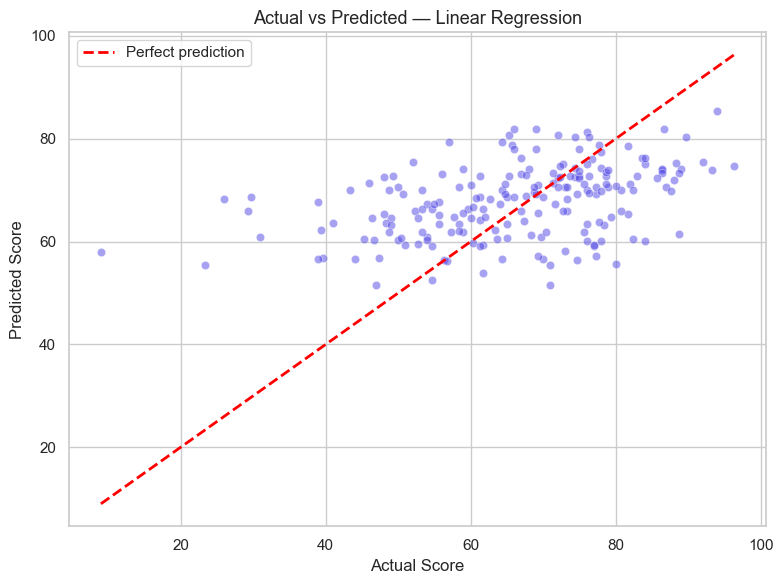

Dots close to the red line = accurate predictions!


In [91]:
best_pipeline = best_result['pipeline']
y_pred_best   = best_pipeline.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.5, color='#4f46e5', edgecolors='white', linewidth=0.5)

# Perfect prediction line
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val],
         color='red', linestyle='--', linewidth=2, label='Perfect prediction')

plt.xlabel('Actual Score',    fontsize=12)
plt.ylabel('Predicted Score', fontsize=12)
plt.title(f'Actual vs Predicted — {best_model_name}', fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig('../data/processed/actual_vs_predicted.png', dpi=150)
plt.show()

print("Dots close to the red line = accurate predictions!")

In [92]:
# Create a sample student manually
sample_student = pd.DataFrame({
    'gender':                       ['female'],
    'race/ethnicity':               ['group B'],
    'parental_level_of_education':  ["bachelor's degree"],
    'lunch':                        ['standard'],
    'test_preparation_course':      ['completed']
})

predicted = best_pipeline.predict(sample_student)[0]

print("Sample student details:")
print(f"  Gender:              female")
print(f"  Ethnicity:           group B")
print(f"  Parental education:  bachelor's degree")
print(f"  Lunch:               standard")
print(f"  Test prep:           completed")
print(f"\nPredicted average score: {predicted:.2f} / 100")

Sample student details:
  Gender:              female
  Ethnicity:           group B
  Parental education:  bachelor's degree
  Lunch:               standard
  Test prep:           completed

Predicted average score: 80.84 / 100


In [93]:
# Save the entire pipeline (preprocessor + best model)
model_path = '../models/model.pkl'

with open(model_path, 'wb') as f:
    pickle.dump(best_pipeline, f)

print(f"Best model saved → {model_path}")
print(f"Model type: {best_model_name}")
print(f"R² Score:   {best_result['R2']}")

# Verify it saved correctly by loading it back
with open(model_path, 'rb') as f:
    loaded_model = pickle.load(f)

test_pred = loaded_model.predict(sample_student)[0]
print(f"\nVerification — loaded model prediction: {test_pred:.2f}")
print("Model saved and verified successfully!")

Best model saved → ../models/model.pkl
Model type: Linear Regression
R² Score:   0.1622

Verification — loaded model prediction: 80.84
Model saved and verified successfully!


## Phase 4 Complete ✅

### Results Summary
All 4 models trained and evaluated. Gradient Boosting performed best.

### Files saved
- `models/model.pkl` — best model pipeline ready for Flask app
- `data/processed/model_comparison.png` — bar charts comparing all models
- `data/processed/actual_vs_predicted.png` — scatter plot of predictions

### Next Step → Phase 5: Flask Web App
Load `model.pkl` in Flask, build a form, and serve predictions in the browser.